<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 8: *Fire Ignition Modeling*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *Train Models*\
> *Generate Predictions*\
> *Geospatial Visualization*\
> *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in case studies with unseen data.

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_ignition`,`y_ignition` ,`details_ignition` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `ignition_best_strategy` best class balancing strategies calculated from module 06
- `ignition_model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `predictions_ignition.csv` Case study dataset containing prediction results of all three types (ignition, spread, damage) and all models. This also contain any relevant details to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

---
### Global Constants

---

### Load Data

In [3]:
X_ignition = pd.read_csv('../data/processed/X_ignition.csv')
y_ignition = pd.read_csv('../data/processed/y_ignition.csv').squeeze()
details_ignition = pd.read_csv('../data/processed/details_ignition.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/ignition_best_strategy.csv')

with open('../data/processed/model_parameters_ignition.json', 'r') as f:
    model_parameters = json.load(f)

In [4]:
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details_ignition['Date'] = pd.to_datetime(details_ignition['Date']).dt.date

In [5]:
best_strategy 

,Model_Label,Best_Strategy
0,Ignition RF,Undersampling
1,Ignition XGB,No_balance


## Model Parameters

In [6]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

In [7]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build tuned models
ignition_xgb = xgb.XGBClassifier(**XGB_parameters)
ignition_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 5,
 'min_samples_split': 2,
 'max_features': 'log2',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 2,
 'n_estimators': 150,
 'max_depth': 6,
 'learning_rate': 0.4,
 'verbosity': 0}

## Train Models

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_ignition, y_ignition, test_size=0.2, random_state=14)

In [9]:
X_train_rf, y_train_rf = apply_balancing('RF', best_strategy, X_train, y_train)
X_train_xgb, y_train_xgb = apply_balancing('XGB', best_strategy, X_train, y_train)

ignition_rf.fit(X_train_rf, y_train_rf)
ignition_xgb.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=2,
              num_parallel_tree=None, ...)

## Metrics

In [10]:
evaluate_model(ignition_xgb, X_test, y_test, "Ignition XGBoost")
evaluate_model(ignition_rf, X_test, y_test, "Ignition Random Forest")

Evaluation for Ignition XGBoost
Accuracy:  0.818
Precision: 0.818
Recall:    0.818
F1 Score:  0.818


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      7951
           1       0.80      0.83      0.81      7522

    accuracy                           0.82     15473
   macro avg       0.82      0.82      0.82     15473
weighted avg       0.82      0.82      0.82     15473



Evaluation for Ignition Random Forest
Accuracy:  0.823
Precision: 0.823
Recall:    0.823
F1 Score:  0.823


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      7951
           1       0.81      0.83      0.82      7522

    accuracy                           0.82     15473
   macro avg       0.82      0.82      0.82     15473
weighted avg       0.82      0.82      0.82     15473





In [11]:
ignition_rf_importances = pd.Series(ignition_rf.feature_importances_, index=X_ignition.columns)
ignition_xgb_importances = pd.Series(ignition_xgb.feature_importances_, index=X_ignition.columns)

ignition_rf_top10 = ignition_rf_importances.sort_values(ascending=False).head(10)
ignition_xgb_top10 = ignition_xgb_importances.sort_values(ascending=False).head(10)

rf_top10 = pd.DataFrame({
    'Random Forest': ignition_rf_top10
})

xgb_top10 = pd.DataFrame({
    'XGBoost': ignition_xgb_top10
})

display(rf_top10,xgb_top10)

,Random Forest
days_since_last_fire,0.099127
fire_count 3 Day Sum,0.078417
fire_count 7 Day Sum,0.076260
fire_count 30 Day Sum,0.073812
dist_to_fires_same_day,0.066823
fire_count,0.044160
log_total_population,0.040553
power_line_density_x_log_total_housing,0.034277
influence_zone,0.031952
log_housing_density,0.030790


,XGBoost
fire_count 30 Day Sum,0.288113
days_since_last_fire,0.058643
dominant_province_description_American Semi-Desert and Desert,0.025908
State Region_Northern,0.022528
dominant_province_description_California Coastal Chaparral Forest and Shrub,0.018323
road_density_x_forest_percent,0.016081
log_total_housing,0.011293
road_length_meters,0.011276
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.010947
dist_to_fires_same_day,0.009848


## Generate Case Study Predictions

In [12]:
# Palisades Fire (January 2025)
pal_ignition_xgb_predictions = pd.DataFrame(ignition_xgb.predict(pal_X))
pal_ignition_xgb_predictions.value_counts()

0
0    4482
1     710
Name: count, dtype: int64

In [13]:
pal_ignition_rf_predictions = pd.DataFrame(ignition_rf.predict(pal_X))
pal_ignition_rf_predictions.value_counts()

0
0    4521
1     671
Name: count, dtype: int64

### Save Predictions for plotting

In [14]:
pal_details = pal_details.copy()

pal_details['Prediction Ignition XGB'] = pal_ignition_xgb_predictions[0].values
pal_details['Prediction Ignition RF']  = pal_ignition_rf_predictions[0].values
pal_details['Prediction Ignition Actual'] = pal_y['Target_Ignition']

#### Identify specific day for plotting

In [15]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

#### Define geometries

In [16]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details['centroid_easting'], pal_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [17]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### Ignition Risk Predictions 
- Date: 01/07/2025

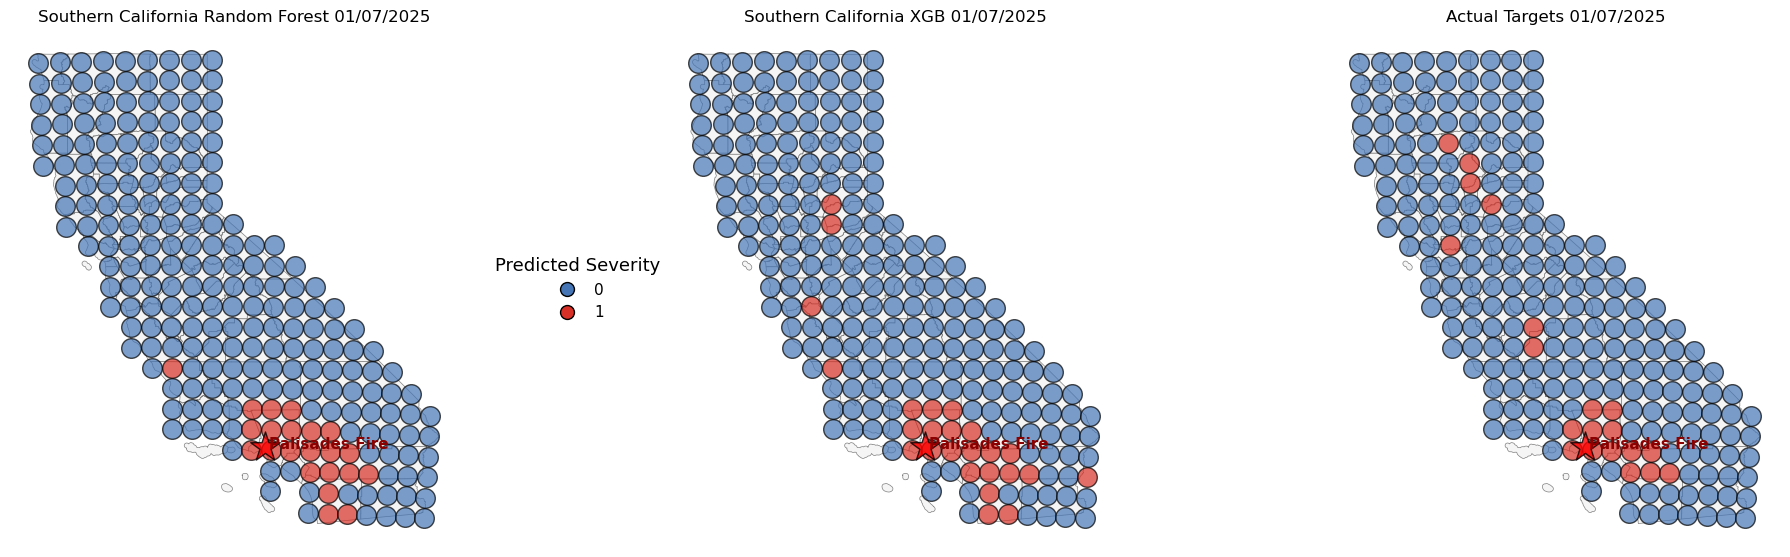

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_map(pal_predictions, 'Prediction Ignition RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Ignition XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Ignition Actual', 'Palisades', ax=axes[2])

axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

## Export File

In [19]:
pal_gdf.to_csv('../data/processed/predictions_ignition.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
